**Navigation:**  
[← Two-Population Structure](05_two_population.ipynb) | [Rt Decomposition](07_rt_wells_riley_decomposition.ipynb) | [Interventions →](08_interventions.ipynb)

# Superspreader Party Crawl: Cluster Re-seeding with General $R_0 < 1$

Goal:
- Keep the general population subcritical in isolation.
- Add high-transmission party clusters.
- Show sparse coupling can re-seed the general population with multiple cases.

**Work in progress:** This notebook does not yet show the intended party-crawl dynamics.

The current version is still a placeholder for a future event-engine implementation. The eventual model should introduce parties dynamically, without explicit manual seeding, so that Party A and Party B emerge at different times and propagate through the general population.

If this notebook is made more graphic later, geographic partitions may help communicate the flow, but that is intentionally deferred for now.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

if "epi" in globals():
    reloader = getattr(epi, "reload_package_modules", None)
    if callable(reloader):
        epi = reloader("epi_structure")
    else:
        print("epi_structure already loaded; restart kernel to pick up package changes.")
        import epi_structure as epi
else:
    import epi_structure as epi

from epi_structure import (
    DiseaseParameters,
    Scenario,
    SimulationParameters,
    StructuredEpidemicModel,
    trajectory_to_df,
)

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
crawl_disease = DiseaseParameters(infectious_period=6.0, latent_period=2.5)
crawl_sim = SimulationParameters(time_step=0.1, duration=180.0, output_stride=10)

crawl_seed = Scenario(
    name='party_crawl_seed',
    description='Seed scenario for party crawl experiments',
    populations=[],
    contact_matrix=[],
    population_names=[],
    simulation=crawl_sim,
    intervention_plan=None,
)

crawl_scenario = (
    Scenario.builder(base=crawl_seed, name='party_crawl_base')
    .disease(crawl_disease)
    .population('general', size=15_000, beta=0.0, initial_infected=8)
    .population('party_a', size=300, beta=0.0, initial_infected=0)
    .population('party_b', size=300, beta=0.0, initial_infected=0)
    # row=recipient, col=source
    .transition('general', 'general', 0.0000065)
    .transition('general', 'party_a', 0.0000300)
    .transition('general', 'party_b', 0.0000300)
    .transition('party_a', 'general', 0.0000040)
    .transition('party_a', 'party_a', 0.0015000)
    .transition('party_a', 'party_b', 0.0002000)
    .transition('party_b', 'general', 0.0000040)
    .transition('party_b', 'party_a', 0.0002000)
    .transition('party_b', 'party_b', 0.0015000)
    .build()
)

crawl_populations = crawl_scenario.populations
crawl_names = crawl_scenario.population_names
C_crawl = np.array(crawl_scenario.contact_matrix, dtype=float)

C_general_only = np.zeros_like(C_crawl)
C_general_only[0, 0] = crawl_scenario['general', 'general']

In [3]:
crawl_traj = StructuredEpidemicModel(
    populations=crawl_populations,
    contact_matrix=C_crawl.tolist(),
    simulation=crawl_sim,
    intervention_plan=None,
).simulate()

general_only_traj = StructuredEpidemicModel(
    populations=crawl_populations,
    contact_matrix=C_general_only.tolist(),
    simulation=crawl_sim,
    intervention_plan=None,
).simulate()

df_crawl = trajectory_to_df(crawl_traj)
df_general_only = trajectory_to_df(general_only_traj)

N_crawl = np.array([p.size for p in crawl_populations], dtype=float)
gamma_crawl = np.array([1.0 / p.disease.infectious_period for p in crawl_populations], dtype=float)
K0_crawl = np.zeros_like(C_crawl)
for i in range(len(crawl_names)):
    for j in range(len(crawl_names)):
        K0_crawl[i, j] = C_crawl[i, j] * N_crawl[i] / gamma_crawl[j]

print('Superspreader crawl setup: K0 at full susceptibility')
print(pd.DataFrame(K0_crawl, index=crawl_names, columns=crawl_names).round(3))
print(f'\nGeneral-alone R (Kgg): {K0_crawl[0,0]:.3f} (< 1 expected)')
print(f'System-level R (spectral radius): {np.max(np.real(np.linalg.eigvals(K0_crawl))):.3f}')

Superspreader crawl setup: K0 at full susceptibility
         general  party_a  party_b
general    0.585     2.70     2.70
party_a    0.007     2.70     0.36
party_b    0.007     0.36     2.70

General-alone R (Kgg): 0.585 (< 1 expected)
System-level R (spectral radius): 3.076


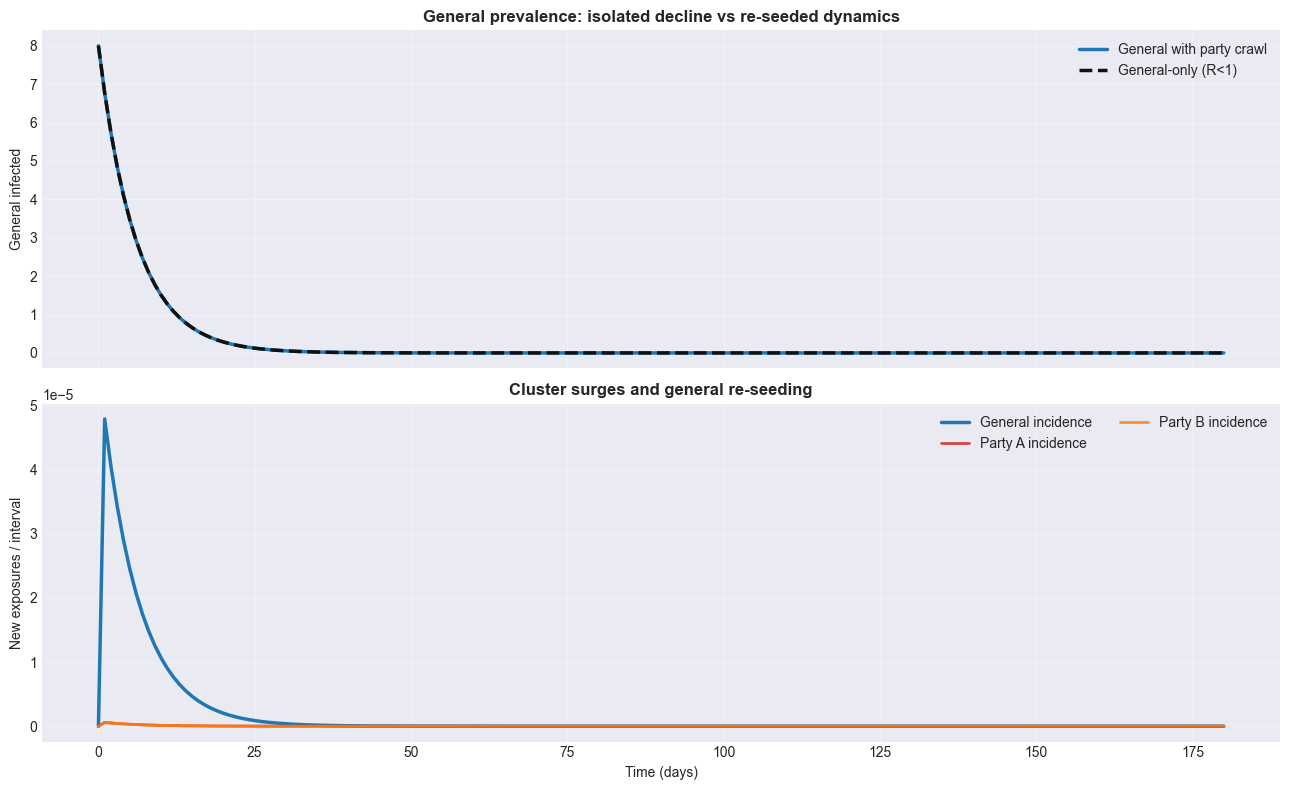


Key contrast:
  Peak general I with party crawl: 8.0
  Peak general I in isolated general-only world: 8.0
  Final general I with party crawl: 0.00
  Final general I in isolated world: 0.00


In [5]:
def pop(df_in: pd.DataFrame, name: str) -> pd.DataFrame:
    return df_in[df_in['population'] == name].copy()

g_crawl = pop(df_crawl, 'general')
g_iso = pop(df_general_only, 'general')
a_crawl = pop(df_crawl, 'party_a')
b_crawl = pop(df_crawl, 'party_b')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(g_crawl['time'], g_crawl['I'], linewidth=2.5, color='#1f77b4', label='General with party crawl')
axes[0].plot(g_iso['time'], g_iso['I'], linewidth=2.5, color='#111111', linestyle='--', label='General-only (R<1)')
axes[0].set_ylabel('General infected')
axes[0].set_title('General prevalence: isolated decline vs re-seeded dynamics', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(g_crawl['time'], g_crawl['new_exposed_interval'], linewidth=2.5, color='#1f77b4', label='General incidence')
axes[1].plot(a_crawl['time'], a_crawl['new_exposed_interval'], linewidth=2.0, color='#d62728', alpha=0.85, label='Party A incidence')
axes[1].plot(b_crawl['time'], b_crawl['new_exposed_interval'], linewidth=2.0, color='#ff7f0e', alpha=0.85, label='Party B incidence')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('New exposures / interval')
axes[1].set_title('Cluster surges and general re-seeding', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

print('\nKey contrast:')
print(f"  Peak general I with party crawl: {g_crawl['I'].max():.1f}")
print(f"  Peak general I in isolated general-only world: {g_iso['I'].max():.1f}")
print(f"  Final general I with party crawl: {g_crawl['I'].iloc[-1]:.2f}")
print(f"  Final general I in isolated world: {g_iso['I'].iloc[-1]:.2f}")

## Deterministic vs Probability Engine

The same party-crawl scenario can also be run with a probability-based transition engine. This keeps each compartment in whole-person counts and introduces run-to-run variation from sampled transitions.

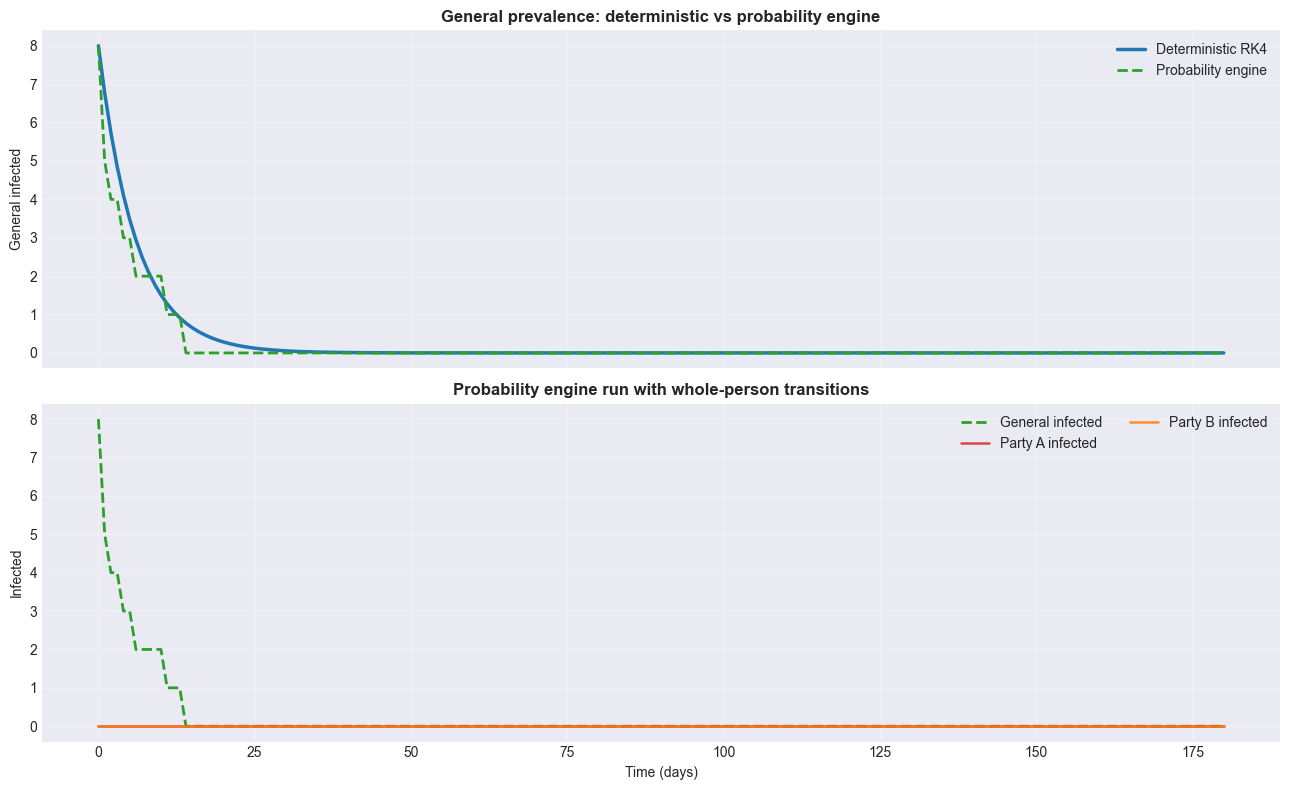


Probability engine summary:
  Peak general I: 8.0
  Final general I: 0.0
  Final party A I: 0.0
  Final party B I: 0.0


In [6]:
crawl_prob_traj = epi.run_scenario(crawl_scenario, engine="probability", seed=42)
df_crawl_prob = trajectory_to_df(crawl_prob_traj)

g_prob = pop(df_crawl_prob, 'general')
a_prob = pop(df_crawl_prob, 'party_a')
b_prob = pop(df_crawl_prob, 'party_b')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(g_crawl['time'], g_crawl['I'], linewidth=2.5, color='#1f77b4', label='Deterministic RK4')
axes[0].plot(g_prob['time'], g_prob['I'], linewidth=2.0, color='#2ca02c', linestyle='--', label='Probability engine')
axes[0].set_ylabel('General infected')
axes[0].set_title('General prevalence: deterministic vs probability engine', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(g_prob['time'], g_prob['I'], linewidth=2.0, color='#2ca02c', linestyle='--', label='General infected')
axes[1].plot(a_prob['time'], a_prob['I'], linewidth=1.8, color='#d62728', alpha=0.85, label='Party A infected')
axes[1].plot(b_prob['time'], b_prob['I'], linewidth=1.8, color='#ff7f0e', alpha=0.85, label='Party B infected')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Infected')
axes[1].set_title('Probability engine run with whole-person transitions', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

print('\nProbability engine summary:')
print(f"  Peak general I: {g_prob['I'].max():.1f}")
print(f"  Final general I: {g_prob['I'].iloc[-1]:.1f}")
print(f"  Final party A I: {a_prob['I'].iloc[-1]:.1f}")
print(f"  Final party B I: {b_prob['I'].iloc[-1]:.1f}")